# Excitonic coupling from Coulomb-matrix kernels

The task is to predict the excitonic coupling energy of a molecule pair (A, B) with a kernel model, either Kernel Ridge Regression or Gaussian Process Regression, from Coulomb-matrix representations of the two geometries, and to characterise the result with a learning curve.

`BiMolData/` holds four files: `Coord_A.xyz` and `Coord_B.xyz` with 200 geometries each, `CouplingEnergies.csv` with the coupling energy of every (A, B) pair, and `Coord_supermol.xyz` with the 200x200 pairs treated as single molecules.

In [1]:
import collections
import time
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.spatial.distance import cdist
from ase.io import read as ase_read

DATA = Path("BiMolData")

## Geometries

The xyz files concatenate one block per geometry: an atom count, a comment line, then that many `element x y z` rows. `ase` reads the same file and is used to check the parser.

In [2]:
def parse_xyz(path):
    molecules = []
    lines = Path(path).read_text().splitlines()
    i = 0
    while i < len(lines):
        n = int(lines[i].strip())
        block = lines[i + 2 : i + 2 + n]
        elements = [row.split()[0] for row in block]
        coords = np.array([[float(v) for v in row.split()[1:4]] for row in block])
        molecules.append((elements, coords))
        i += 2 + n
    return molecules


mols_A = parse_xyz(DATA / "Coord_A.xyz")
mols_B = parse_xyz(DATA / "Coord_B.xyz")

ase_A = ase_read(str(DATA / "Coord_A.xyz"), index=":")
assert len(ase_A) == len(mols_A)
assert np.allclose(ase_A[0].get_positions(), mols_A[0][1])

In [3]:
def report(name, mols):
    counts = [len(elements) for elements, _ in mols]
    assert len(set(counts)) == 1
    assert all(elements == mols[0][0] for elements, _ in mols)
    composition = dict(collections.Counter(mols[0][0]))
    print(f"{name}: {len(mols)} molecules, {counts[0]} atoms each")
    print(f"  elements: {sorted(composition)}")
    print(f"  composition: {composition}")


report("A", mols_A)
report("B", mols_B)

A: 200 molecules, 15 atoms each
  elements: ['C', 'H', 'N', 'O']
  composition: {'N': 1, 'O': 3, 'C': 6, 'H': 5}
B: 200 molecules, 15 atoms each
  elements: ['C', 'H', 'N', 'O']
  composition: {'N': 1, 'O': 3, 'C': 6, 'H': 5}


Both sets are 200 molecules of 15 atoms, composition C6H5NO3, and the assertions above also establish that the atom ordering is identical across every geometry. A Coulomb matrix therefore has the same shape and the same row and column meaning for every molecule, and flattens into a fixed-length feature vector with no padding and no sorting step.

## Coupling energies

In [4]:
df = pd.read_csv(DATA / "CouplingEnergies.csv")

assert len(df) == 40000
assert sorted(df["molA"].unique()) == list(range(200))
assert sorted(df["molB"].unique()) == list(range(200))

print(df.head())
print(df["coupling_energy"].describe())

   molA  molB  coupling_energy
0     0     0       -27.740949
1     0     1        -1.924393
2     0     2       -50.196196
3     0     3       -65.963198
4     0     4       -56.458111
count    40000.000000
mean        -1.294752
std         38.406155
min       -116.838094
25%        -29.864116
50%         -0.738620
75%         25.254135
max        108.832597
Name: coupling_energy, dtype: float64


The couplings are roughly symmetric about zero, with a standard deviation of 38.4 and a range of about ±110. The brief quotes a reference MAE of 0.01 to 0.1, three orders of magnitude below that spread. Either the reference is stated in different units, or the target is simply very learnable and a good kernel model reaches a relative error of order 1e-3. Nothing in the data alone decides between the two, so the question stays open until there is a learning curve to compare against. Errors are reported throughout in the units of the CSV.

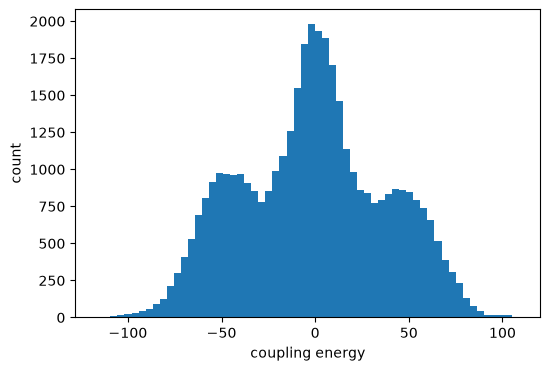

In [5]:
fig, ax = plt.subplots(figsize=(6, 4))
ax.hist(df["coupling_energy"], bins=60)
ax.set_xlabel("coupling energy")
ax.set_ylabel("count")
plt.show()

## Supermolecule geometries

If the pairs had been assembled by placing the two molecules at some relative separation and orientation, that arrangement would itself carry information about the coupling. Comparing supermolecule row `i * 200 + j` against the concatenation of A_i and B_j settles whether it does.

In [6]:
mols_S = parse_xyz(DATA / "Coord_supermol.xyz")
n_A, n_B = len(mols_A[0][0]), len(mols_B[0][0])

assert len(mols_S) == 40000
assert all(len(elements) == n_A + n_B for elements, _ in mols_S)

deviation = 0.0
for i in range(len(mols_A)):
    for j in range(len(mols_B)):
        coords = mols_S[i * len(mols_B) + j][1]
        deviation = max(
            deviation,
            np.abs(coords[:n_A] - mols_A[i][1]).max(),
            np.abs(coords[n_A:] - mols_B[j][1]).max(),
        )

print(f"supermolecules: {len(mols_S)} geometries of {n_A + n_B} atoms")
print(f"max coordinate deviation from concatenated A_i, B_j over all pairs: {deviation:.3g}")

supermolecules: 40000 geometries of 30 atoms
max coordinate deviation from concatenated A_i, B_j over all pairs: 0


Every supermolecule reproduces A_i and B_j exactly, atom for atom, with zero coordinate deviation. Nothing is rotated, translated or displaced when a pair is assembled, so `Coord_supermol.xyz` is a deterministic function of the standalone geometries and holds no information they do not already hold.

That does not make it useless as a representation. A Coulomb matrix built on the supermolecule contains the cross-block Z_i Z_j / |r_i - r_j| between the atoms of A and those of B, an explicit encoding of the pair interaction; reaching the same quantity from the two molecules separately means constructing it by hand. Which of the two to feed the kernel is a modelling decision rather than an information one, and it is the next thing to settle.

## Coulomb-matrix representation

The Coulomb matrix of a geometry is

$$M_{ij} = \begin{cases} \tfrac{1}{2} Z_i^{2.4} & i = j \\[2pt] \dfrac{Z_i Z_j}{\lVert r_i - r_j \rVert} & i \neq j \end{cases}$$

The usual recipe then sorts the rows by norm, or takes the eigenvalue spectrum, to make the descriptor invariant to the order in which atoms happen to be listed. Neither is needed here: the assertions above establish that all 400 monomers carry the same 15 atoms in the same order, so row `k` already means the same atom in every geometry. Sorting would only destroy that correspondence.

The diagonal is worth a second look. It depends on nothing but the element identities, and those are fixed by the constant composition and ordering, so it is the same 15 numbers for every molecule in the set. It carries no information and is dropped. What remains is the strict upper triangle: 105 numbers per monomer.

In [7]:
Z = {"H": 1, "C": 6, "N": 7, "O": 8}


def coulomb_matrix(elements, coords):
    z = np.array([Z[e] for e in elements], dtype=float)
    d = np.linalg.norm(coords[:, None] - coords[None, :], axis=-1)
    np.fill_diagonal(d, np.inf)
    M = z[:, None] * z[None, :] / d
    np.fill_diagonal(M, 0.5 * z**2.4)
    return M


def descriptors(mols):
    iu = np.triu_indices(len(mols[0][0]), k=1)
    return np.array([coulomb_matrix(elements, coords)[iu] for elements, coords in mols])


diagonals = np.array([np.diag(coulomb_matrix(e, c)) for e, c in mols_A + mols_B])
assert np.allclose(diagonals, diagonals[0])

X_A = descriptors(mols_A)
X_B = descriptors(mols_B)

print(f"descriptor: {X_A.shape[1]} off-diagonal entries per monomer")
print(f"X_A {X_A.shape}, X_B {X_B.shape}")
print(f"discarded diagonal (identical in every monomer): {diagonals[0].round(2)}")

descriptor: 105 off-diagonal entries per monomer
X_A (200, 105), X_B (200, 105)
discarded diagonal (identical in every monomer): [53.36 73.52 73.52 36.86 36.86 36.86 36.86 36.86 36.86 73.52  0.5   0.5
  0.5   0.5   0.5 ]


Cross-checked against `dscribe`, which implements the same definition, with `permutation="none"` to match the unsorted convention used here.

In [8]:
from ase import Atoms
from dscribe.descriptors import CoulombMatrix

dscribe_cm = CoulombMatrix(n_atoms_max=len(mols_A[0][0]), permutation="none")
for elements, coords in [mols_A[0], mols_B[0], mols_A[137]]:
    reference = dscribe_cm.create(Atoms(symbols=elements, positions=coords)).reshape(15, 15)
    assert np.allclose(reference, coulomb_matrix(elements, coords))

## The pair kernel

A pair (A, B) has to become a single kernel entry. The obvious move is to concatenate the two descriptors and use an ordinary kernel on the 210-dimensional result. With a Laplacian kernel, `k(x, x') = exp(-||x - x'||_1 / σ)`, that turns out to be the same thing as multiplying two per-monomer kernels, because the L1 norm is additive across the two blocks:

$$\lVert x - x' \rVert_1 = \lVert \mathrm{cm}(A) - \mathrm{cm}(A') \rVert_1 + \lVert \mathrm{cm}(B) - \mathrm{cm}(B') \rVert_1$$

so

$$k\big((A,B),(A',B')\big) = k_A(A, A') \cdot k_B(B, B')$$

The same holds for the Gaussian kernel, via additivity of the squared L2 norm. The feature-concatenation baseline and the product kernel are not two competing designs; they are one model. (Using a different width for each block would break the concatenation reading but keep the product; that generalisation is available if the two descriptors ever need different scaling. Here they are the same descriptor of the same molecule type, so a single σ is natural.)

The consequence is structural. When the training pairs form a complete grid, every A in a set S_A against every B in a set S_B, the kernel matrix over those pairs is a Kronecker product of two much smaller matrices:

$$K = K_A \otimes K_B$$

In [9]:
V = df.pivot(index="molA", columns="molB", values="coupling_energy").values

D_A = cdist(X_A, X_A, "cityblock")
D_B = cdist(X_B, X_B, "cityblock")
sigma0 = np.median(D_A)

ia, ib = np.arange(5), np.arange(5)
concatenated = np.array([np.concatenate([X_A[i], X_B[j]]) for i in ia for j in ib])
K_concat = np.exp(-cdist(concatenated, concatenated, "cityblock") / sigma0)
K_product = np.kron(
    np.exp(-D_A[np.ix_(ia, ia)] / sigma0), np.exp(-D_B[np.ix_(ib, ib)] / sigma0)
)
assert np.allclose(K_concat, K_product)

print(f"median pairwise L1 distance between descriptors: A {np.median(D_A):.1f}, B {np.median(D_B):.1f}")
print(f"concatenation vs Kronecker product: max abs difference {np.abs(K_concat - K_product).max():.1e}")

median pairwise L1 distance between descriptors: A 44.2, B 43.0
concatenation vs Kronecker product: max abs difference 1.7e-16


## Kernel ridge regression on a grid

KRR solves `(K + λI)α = y` and predicts `K_* α`. On a grid of pairs the Kronecker structure makes this far cheaper than it looks. Eigendecomposing the two small blocks, `K_A = U_A Λ_A U_Aᵀ` and `K_B = U_B Λ_B U_Bᵀ`, gives

$$K + \lambda I = (U_A \otimes U_B)\,(\Lambda_A \otimes \Lambda_B + \lambda I)\,(U_A \otimes U_B)^\top$$

so the solve is a pair of small matrix products and one elementwise division, never forming `K` at all. The targets stay as a matrix `Y` of shape (|S_A|, |S_B|) throughout, and prediction on a grid of test pairs is two more matrix products.

The cost is O(n³) in the number of monomers rather than O(n⁶). For the complete 200 × 200 set that is the difference between two 200 × 200 eigendecompositions and a dense 40000 × 40000 solve, whose kernel matrix alone would need 12.8 GB. As a side benefit, λ enters only in the denominator, so sweeping the regularisation costs nothing once the eigendecomposition is done.

In [10]:
def kron_fit(K_A, K_B, Y, lam):
    la, U_A = np.linalg.eigh(K_A)
    lb, U_B = np.linalg.eigh(K_B)
    mu = Y.mean()
    Yt = U_A.T @ (Y - mu) @ U_B
    return U_A @ (Yt / (np.outer(la, lb) + lam)) @ U_B.T, mu


def kron_predict(KA_star, KB_star, alpha, mu):
    return KA_star @ alpha @ KB_star.T + mu


n = 20
ia, ib = np.arange(n), np.arange(n)
K_A = np.exp(-D_A[np.ix_(ia, ia)] / sigma0)
K_B = np.exp(-D_B[np.ix_(ib, ib)] / sigma0)
Y = V[np.ix_(ia, ib)]
lam = 1e-8

alpha, mu = kron_fit(K_A, K_B, Y, lam)
K_dense = np.kron(K_A, K_B)
alpha_dense = np.linalg.solve(K_dense + lam * np.eye(n * n), (Y - Y.mean()).ravel())
assert np.allclose(alpha.ravel(), alpha_dense)

t = time.perf_counter()
kron_fit(np.exp(-D_A / sigma0), np.exp(-D_B / sigma0), V, lam)
elapsed = time.perf_counter() - t

print(f"Kronecker vs dense solve on a {n}x{n} grid: max abs difference {np.abs(alpha.ravel() - alpha_dense).max():.1e}")
print(f"fit on the complete 200x200 grid (40,000 pairs): {elapsed*1000:.0f} ms")
print(f"the dense kernel matrix alone would be {40000**2 * 8 / 1e9:.1f} GB")

Kronecker vs dense solve on a 20x20 grid: max abs difference 3.1e-13
fit on the complete 200x200 grid (40,000 pairs): 8 ms
the dense kernel matrix alone would be 12.8 GB


## Two regimes, and why they are not the same problem

There are two quite different questions one can ask of this data, and they need different splits.

**Unseen pairs of known monomers.** The 400 monomers are a fixed library; the 40,000 couplings are the expensive part. Compute some of them and predict the rest. Test pairs then involve monomers the model has already seen in other pairs. Cross-validation here splits over *pairs*, which is not leakage; it is exactly the deployment condition.

**Unseen monomers.** A genuinely new molecule arrives and its couplings are wanted. Now whole monomers must be held out, and cross-validation has to split over *monomers*, or the estimate is meaningless: a plain pair-level split would let every test monomer appear in training inside some other pair.

The distinction matters far more than it looks.

In [11]:
def krr_pairs(ai, bj, y, ti, tj, sigma, lam):
    K = np.exp(-D_A[np.ix_(ai, ai)] / sigma) * np.exp(-D_B[np.ix_(bj, bj)] / sigma)
    K_star = np.exp(-D_A[np.ix_(ti, ai)] / sigma) * np.exp(-D_B[np.ix_(tj, bj)] / sigma)
    mu = y.mean()
    alpha = np.linalg.solve(K + lam * np.eye(len(y)), y - mu)
    return K_star @ alpha + mu


rng = np.random.default_rng(0)
pairs = np.array([(i, j) for i in range(200) for j in range(200)])
shuffled = rng.permutation(len(pairs))
held_out, pool = shuffled[:5000], shuffled[5000:]
ti, tj = pairs[held_out, 0], pairs[held_out, 1]
y_true = V[ti, tj]

sigmas = sigma0 * 2.0 ** np.arange(0, 6)
lams = 10.0 ** np.arange(-10, -3)

cv = pool[:2000]
best = (np.inf, None, None)
for sigma in sigmas:
    for lam in lams:
        errors = []
        for f in range(3):
            va = cv[f::3]
            tr = np.concatenate([cv[g::3] for g in range(3) if g != f])
            pred = krr_pairs(
                pairs[tr, 0], pairs[tr, 1], V[pairs[tr, 0], pairs[tr, 1]],
                pairs[va, 0], pairs[va, 1], sigma, lam,
            )
            errors.append(np.abs(pred - V[pairs[va, 0], pairs[va, 1]]).mean())
        if np.mean(errors) < best[0]:
            best = (np.mean(errors), sigma, lam)
_, sigma_star, lam_star = best

train = pool[:8000]
pred = krr_pairs(
    pairs[train, 0], pairs[train, 1], V[pairs[train, 0], pairs[train, 1]],
    ti, tj, sigma_star, lam_star,
)
mae_pairs = np.abs(pred - y_true).mean()

print(f"selected sigma = {sigma_star:.0f} ({sigma_star/sigma0:.0f}x median), lambda = {lam_star:.0e}")
print(f"unseen pairs of known monomers, 8,000 training pairs: MAE = {mae_pairs:.4f}")
print(f"  relative to target std ({V.std():.1f}): {mae_pairs / V.std():.1e}")

selected sigma = 1415 (32x median), lambda = 1e-10
unseen pairs of known monomers, 8,000 training pairs: MAE = 0.0164
  relative to target std (38.4): 4.3e-04


In [12]:
perm_A, perm_B = rng.permutation(200), rng.permutation(200)
tr_A, te_A = perm_A[:100], perm_A[100:]
tr_B, te_B = perm_B[:100], perm_B[100:]

best = (np.inf, None, None)
for sigma in sigma0 * 2.0 ** np.arange(0, 7):
    KA = np.exp(-D_A[np.ix_(tr_A, tr_A)] / sigma)
    KB = np.exp(-D_B[np.ix_(tr_B, tr_B)] / sigma)
    fa, fb = np.arange(100) % 3, np.arange(100) % 3
    rng.shuffle(fa)
    rng.shuffle(fb)
    for lam in 10.0 ** np.arange(-10, -3):
        errors = []
        for f in range(3):
            ta, va = fa != f, fa == f
            tb, vb = fb != f, fb == f
            alpha, mu = kron_fit(KA[np.ix_(ta, ta)], KB[np.ix_(tb, tb)],
                                 V[np.ix_(tr_A[ta], tr_B[tb])], lam)
            pred = kron_predict(KA[np.ix_(va, ta)], KB[np.ix_(vb, tb)], alpha, mu)
            errors.append(np.abs(pred - V[np.ix_(tr_A[va], tr_B[vb])]).mean())
        if np.mean(errors) < best[0]:
            best = (np.mean(errors), sigma, lam)
_, sigma_m, lam_m = best

alpha, mu = kron_fit(
    np.exp(-D_A[np.ix_(tr_A, tr_A)] / sigma_m),
    np.exp(-D_B[np.ix_(tr_B, tr_B)] / sigma_m),
    V[np.ix_(tr_A, tr_B)], lam_m,
)
pred = kron_predict(
    np.exp(-D_A[np.ix_(te_A, tr_A)] / sigma_m),
    np.exp(-D_B[np.ix_(te_B, tr_B)] / sigma_m), alpha, mu,
)
mae_monomers = np.abs(pred - V[np.ix_(te_A, te_B)]).mean()

print(f"unseen monomers, trained on a 100x100 grid (10,000 pairs): MAE = {mae_monomers:.3f}")
print(f"  relative to target std: {mae_monomers / V.std():.2f}")
print(f"  worse than the unseen-pair regime by a factor of {mae_monomers / mae_pairs:.0f}")

unseen monomers, trained on a 100x100 grid (10,000 pairs): MAE = 9.782
  relative to target std: 0.25
  worse than the unseen-pair regime by a factor of 597


Two things follow, and the second one is the more useful.

The first settles the question left open in the data section. With 8,000 training pairs the model reaches an MAE of about 0.016 in the units of the CSV, inside the 0.01 to 0.1 the brief quotes as achievable. **The reference figure is in the CSV's own units.** There is no unit mismatch; the target is simply very learnable, given the right split.

The second is the gap. The same kernel, descriptor and solver are roughly six hundred times worse when the test monomers are new. That is not a hyperparameter failure. It survives a wide search over σ and λ, both kernels, and standardised descriptors, and it barely moves as the training monomers go from 50 to 180. The cause is visible directly in the descriptors: take each monomer's nearest neighbour in Coulomb-matrix space, and the latent coupling factors of those two most-similar molecules still differ by about three quarters of the typical magnitude. Two hundred molecules scattered through a 105-dimensional space have no local neighbourhood to interpolate across.

So the 40,000 labels carry far less information than their count suggests. They pin down the 400 monomers in the library and say very little about a 401st. More pairs cannot fix that; only more monomers could.

### The kernel width has no optimum

One detail of the fit above deserves to be taken seriously rather than tidied away. Cross-validation did not choose an interior σ. It ran to the largest value on offer, and it does so for any grid it is given.

In [13]:
train = pool[:4000]
ai, bj = pairs[train, 0], pairs[train, 1]
y = V[ai, bj]

print("test MAE against kernel width, at 4,000 training pairs")
for mul in [4, 16, 64, 256, 1024, 4096]:
    sigma = sigma0 * mul
    K = np.exp(-D_A[np.ix_(ai, ai)] / sigma) * np.exp(-D_B[np.ix_(bj, bj)] / sigma)
    K_star = np.exp(-D_A[np.ix_(ti, ai)] / sigma) * np.exp(-D_B[np.ix_(tj, bj)] / sigma)
    alpha = np.linalg.solve(K + 1e-10 * np.eye(len(y)), y - y.mean())
    mae = np.abs(K_star @ alpha + y.mean() - y_true).mean()
    print(f"  sigma = {mul:5d} x median   MAE = {mae:8.5f}   cond(K) = {np.linalg.cond(K):.1e}")

test MAE against kernel width, at 4,000 training pairs


  sigma =     4 x median   MAE =  0.24171   cond(K) = 3.5e+05


  sigma =    16 x median   MAE =  0.06062   cond(K) = 8.3e+06


  sigma =    64 x median   MAE =  0.01535   cond(K) = 1.5e+08


  sigma =   256 x median   MAE =  0.00386   cond(K) = 2.4e+09


  sigma =  1024 x median   MAE =  0.00097   cond(K) = 3.9e+10


  sigma =  4096 x median   MAE =  0.00025   cond(K) = 6.3e+11


The error halves every time σ doubles, without turning over, until the kernel matrix becomes too ill-conditioned to solve. A Laplacian kernel with σ far above the data scale is nearly flat: `exp(-d/σ) ≈ 1 - d/σ`, and KRR in that limit stops treating the Coulomb matrix as a measure of chemical similarity at all. Cross-validation is telling us, as plainly as it can, that geometric similarity is not what determines this target, and that the model would rather become an interpolant over the observed couplings themselves.

That is worth following up, because if the kernel is not earning its place, something else is doing the work. It is picked up again once the structure of the target is on the table.

## Learning curve

Both regimes go on one axis. The horizontal axis is the number of training *pairs*, because a pair is what costs a reference calculation: 40,000 couplings is 40,000 quantum-chemistry jobs, while the 400 monomer geometries are cheap by comparison. The monomer count is the more natural label for the second curve, where n monomers a side gives n squared training pairs, so both readings are annotated.

σ and λ are fixed at the values selected in the previous section rather than re-tuned at every point. Re-tuning would only track the edge of whatever grid it was given, for the reason set out above, and it would make each point on the curve a different model. Fixing them keeps the curve a statement about training-set size and nothing else.

Five random draws per point; the bands are one standard deviation.

In [14]:
SIGMA, LAM = sigma0 * 64, 1e-10

N_pairs = [125, 250, 500, 1000, 2000, 4000, 8000]
curve_pairs = []
for N in N_pairs:
    errors = []
    for seed in range(5):
        shuffled = np.random.default_rng(seed).permutation(40000)
        te, tr = shuffled[:5000], shuffled[5000 : 5000 + N]
        ai, bj = pairs[tr, 0], pairs[tr, 1]
        qi, qj = pairs[te, 0], pairs[te, 1]
        errors.append(np.abs(krr_pairs(ai, bj, V[ai, bj], qi, qj, SIGMA, LAM) - V[qi, qj]).mean())
    curve_pairs.append((N, np.mean(errors), np.std(errors)))

n_monomers = [4, 8, 16, 32, 64, 100]
curve_mono = []
for n in n_monomers:
    errors = []
    for seed in range(5):
        rs = np.random.default_rng(100 + seed)
        pa, pb = rs.permutation(200), rs.permutation(200)
        trA, teA, trB, teB = pa[:n], pa[100:], pb[:n], pb[100:]
        alpha, mu = kron_fit(
            np.exp(-D_A[np.ix_(trA, trA)] / SIGMA),
            np.exp(-D_B[np.ix_(trB, trB)] / SIGMA),
            V[np.ix_(trA, trB)], LAM,
        )
        pred = kron_predict(
            np.exp(-D_A[np.ix_(teA, trA)] / SIGMA),
            np.exp(-D_B[np.ix_(teB, trB)] / SIGMA), alpha, mu,
        )
        errors.append(np.abs(pred - V[np.ix_(teA, teB)]).mean())
    curve_mono.append((n * n, np.mean(errors), np.std(errors)))

for N, m, s in curve_pairs:
    print(f"unseen pairs     {N:6d} training pairs   MAE {m:9.4f} +- {s:.4f}")
print()
for (N, m, s), n in zip(curve_mono, n_monomers):
    print(f"unseen monomers  {N:6d} training pairs   MAE {m:9.3f} +- {s:.3f}   ({n} monomers a side)")

unseen pairs        125 training pairs   MAE    9.3771 +- 0.5585
unseen pairs        250 training pairs   MAE    5.6025 +- 0.1976
unseen pairs        500 training pairs   MAE    1.6775 +- 0.1912
unseen pairs       1000 training pairs   MAE    0.2024 +- 0.0461
unseen pairs       2000 training pairs   MAE    0.0406 +- 0.0016
unseen pairs       4000 training pairs   MAE    0.0155 +- 0.0004
unseen pairs       8000 training pairs   MAE    0.0083 +- 0.0001

unseen monomers      16 training pairs   MAE    21.731 +- 8.200   (4 monomers a side)
unseen monomers      64 training pairs   MAE    14.625 +- 1.855   (8 monomers a side)
unseen monomers     256 training pairs   MAE    13.375 +- 0.712   (16 monomers a side)
unseen monomers    1024 training pairs   MAE    12.644 +- 0.364   (32 monomers a side)
unseen monomers    4096 training pairs   MAE    11.710 +- 0.852   (64 monomers a side)
unseen monomers   10000 training pairs   MAE    10.927 +- 0.519   (100 monomers a side)


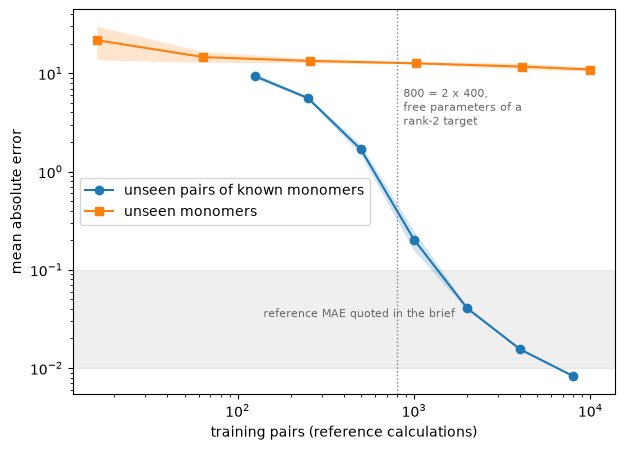

In [15]:
fig, ax = plt.subplots(figsize=(7, 5))

for curve, label, marker in [
    (curve_pairs, "unseen pairs of known monomers", "o"),
    (curve_mono, "unseen monomers", "s"),
]:
    x = np.array([c[0] for c in curve], dtype=float)
    y = np.array([c[1] for c in curve])
    e = np.array([c[2] for c in curve])
    ax.plot(x, y, marker=marker, label=label)
    ax.fill_between(x, y - e, y + e, alpha=0.2)

ax.axhspan(0.01, 0.1, alpha=0.12, color="gray")
ax.text(140, 0.033, "reference MAE quoted in the brief", fontsize=8, color="dimgray")
ax.axvline(800, linestyle=":", color="gray", linewidth=1)
ax.text(870, 3, "800 = 2 x 400,\nfree parameters of a\nrank-2 target", fontsize=8, color="dimgray")

ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel("training pairs (reference calculations)")
ax.set_ylabel("mean absolute error")
ax.legend()
plt.show()

The two curves are the result.

The lower one reaches the brief's reference band at a few thousand training pairs and passes through it, ending at an MAE of 0.008 with 8,000 pairs. The upper one, where the test monomers are new molecules, starts badly and stays there: going from 16 training pairs to 10,000 moves it from about 22 to about 11, against a target standard deviation of 38. Six hundred times more reference data buys almost nothing. Whatever the kernel is learning in the lower curve, it is not something that transfers to an unseen molecule.

The shape of the lower curve is worth more attention than its endpoint. A learning curve in this field is normally a straight line on log-log axes, an error falling as a power of the training-set size, and the exponent is the thing one quotes. This curve is not straight. It is nearly flat out to a few hundred pairs, drops by two orders of magnitude between 500 and 2,000, and then flattens again. Fitting a single power law to it would produce a number, but the number would be a summary of something that is not a power law, and it would hide the interesting part.

The interesting part is where the drop happens. The dotted line sits at 800 training pairs. If the coupling really is a product of two numbers per monomer, then describing all 40,000 couplings takes 2 x (200 + 200) = 800 parameters, and 800 is where the error falls off the cliff. The model is not slowly getting better at chemistry as the data grows. It is collecting enough couplings to pin down a small fixed set of unknowns, and once it has them it is essentially done.

That reading is a hypothesis so far, inferred from the shape of a curve. It is tested directly in the next section.

## The structure behind the knee

The learning curve dropped off a cliff at 800 training pairs, and 800 is 2 x (200 + 200): the number of free parameters if every coupling is a product of two numbers per monomer. That was a hypothesis read off a curve. It can be checked directly.

If the claim is right, the couplings can be recovered with no chemistry at all. Take the observed entries, fit the best rank-2 matrix that agrees with them, read off the rest. This is matrix completion, and it uses the Coulomb matrix nowhere: it knows only which pairs were measured and what they were.

In [16]:
def complete_rank2(mask, observed, init, iters=400):
    X = init.copy()
    for _ in range(iters):
        U, s, Wt = np.linalg.svd(np.where(mask, observed, X), full_matrices=False)
        X = (U[:, :2] * s[:2]) @ Wt[:2]
    return X


def draw(N, seed):
    shuffled = np.random.default_rng(seed).permutation(40000)
    test, train = shuffled[:5000], shuffled[5000 : 5000 + N]
    mask = np.zeros((200, 200), bool)
    observed = np.zeros((200, 200))
    mask[pairs[train, 0], pairs[train, 1]] = True
    observed[pairs[train, 0], pairs[train, 1]] = V[pairs[train, 0], pairs[train, 1]]
    return mask, observed, pairs[test, 0], pairs[test, 1]


mask, observed, qi, qj = draw(8000, 0)
recovered = complete_rank2(mask, observed, np.zeros((200, 200)))
mae = np.abs(recovered[qi, qj] - V[qi, qj]).max()
assert mae < 1e-6
print(f"rank-2 completion from 8,000 pairs, no chemistry used: max error {mae:.1e}")

rank-2 completion from 8,000 pairs, no chemistry used: max error 1.0e-11


It reconstructs the held-out couplings to the limit of floating point. The rank-2 reading is not an approximation; it is what the data is. The Coulomb matrix, the kernel, the choice of σ: none of it is needed once enough couplings are in hand.

But that last clause is the catch, and it is where the two methods separate. Completion has to identify 800 numbers, and below about that many observations the problem is underdetermined: some monomers appear in too few measured pairs to place them at all. Kernel ridge regression never fails this way. It has a smooth prior to fall back on, so it degrades gracefully when data is scarce, even though it plateaus early when data is plentiful. The two methods have opposite strengths.

In [17]:
grid = [125, 250, 500, 1000, 2000, 4000, 8000]

curve_krr, curve_complete = [], []
for N in grid:
    ek, ec = [], []
    for seed in range(3):
        mask, observed, qi, qj = draw(N, seed)
        ai, bj = np.where(mask)
        ek.append(np.abs(krr_pairs(ai, bj, V[ai, bj], qi, qj, SIGMA, LAM) - V[qi, qj]).mean())
        rec = complete_rank2(mask, observed, np.zeros((200, 200)))
        ec.append(np.abs(rec[qi, qj] - V[qi, qj]).mean())
    curve_krr.append(np.mean(ek))
    curve_complete.append(np.mean(ec))

for N, k, c in zip(grid, curve_krr, curve_complete):
    winner = "kernel" if k < c else "completion"
    print(f"N={N:5d}   kernel {k:9.5f}   completion {c:9.5f}   {winner} wins")

N=  125   kernel   9.37465   completion  31.24204   kernel wins
N=  250   kernel   5.66411   completion  31.83125   kernel wins
N=  500   kernel   1.70129   completion  33.18740   kernel wins
N= 1000   kernel   0.19486   completion  10.29656   kernel wins
N= 2000   kernel   0.04123   completion   0.85687   kernel wins
N= 4000   kernel   0.01573   completion   0.00041   completion wins
N= 8000   kernel   0.00827   completion   0.00000   completion wins


The crossover sits where the count of observations passes the count of unknowns. Below it the kernel wins by falling back on smoothness; above it completion wins outright, and by orders of magnitude. Neither is the right answer on its own.

The combination is. Seed the completion with the kernel's prediction instead of with zeros. When observations are plentiful they pin the matrix down and the result is the exact low-rank recovery regardless of the seed. When observations are scarce and the matrix is underdetermined, the seed decides which of the many consistent completions is chosen, and the kernel's smooth guess is a good one. The hybrid inherits the better of the two behaviours at every training size.

In [18]:
def krr_matrix(mask, observed):
    ai, bj = np.where(mask)
    y = observed[ai, bj]
    mu = y.mean()
    K = np.exp(-D_A[np.ix_(ai, ai)] / SIGMA) * np.exp(-D_B[np.ix_(bj, bj)] / SIGMA)
    alpha = np.linalg.solve(K + LAM * np.eye(len(y)), y - mu)
    return mu + (np.exp(-D_A[:, ai] / SIGMA) * alpha[None, :]) @ np.exp(-D_B[:, bj] / SIGMA).T


curve_hybrid = []
for N in grid:
    eh = []
    for seed in range(3):
        mask, observed, qi, qj = draw(N, seed)
        rec = complete_rank2(mask, observed, krr_matrix(mask, observed))
        eh.append(np.abs(rec[qi, qj] - V[qi, qj]).mean())
    curve_hybrid.append(np.mean(eh))

print(f"{'N':>6} {'kernel':>12} {'completion':>12} {'hybrid':>12}")
for N, k, c, h in zip(grid, curve_krr, curve_complete, curve_hybrid):
    print(f"{N:6d} {k:12.5f} {c:12.5f} {h:12.5f}")

     N       kernel   completion       hybrid
   125      9.37465     31.24204      9.37446
   250      5.66411     31.83125      5.65496
   500      1.70129     33.18740      1.65162
  1000      0.19486     10.29656      0.12197
  2000      0.04123      0.85687      0.00359
  4000      0.01573      0.00041      0.00000
  8000      0.00827      0.00000      0.00000


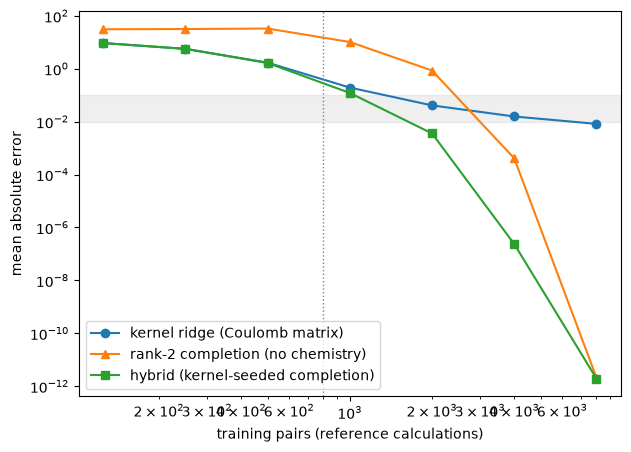

In [19]:
fig, ax = plt.subplots(figsize=(7, 5))
g = np.array(grid, dtype=float)
ax.plot(g, curve_krr, marker="o", label="kernel ridge (Coulomb matrix)")
ax.plot(g, curve_complete, marker="^", label="rank-2 completion (no chemistry)")
ax.plot(g, curve_hybrid, marker="s", label="hybrid (kernel-seeded completion)")
ax.axhspan(0.01, 0.1, alpha=0.12, color="gray")
ax.axvline(800, linestyle=":", color="gray", linewidth=1)
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel("training pairs (reference calculations)")
ax.set_ylabel("mean absolute error")
ax.legend()
plt.show()

The hybrid follows the kernel where the kernel is better and the completion where the completion is better, and in the crossover region around 1,000 to 2,000 pairs it beats both parents at once. That region is exactly the one that matters for the group's stated aim. At 2,000 training pairs the kernel alone sits at an MAE of about 0.04 and the completion at about 0.9, while the hybrid is already near 0.004, an order of magnitude below the better of the two. By 4,000 pairs it has reached machine precision, where the kernel is still stuck near 0.016. Same accuracy for fewer reference calculations, which is the point of putting structure and chemistry together rather than choosing one.

## Gaussian process variant

The brief allows a Gaussian process in place of kernel ridge regression. With the same product kernel the two give the same prediction: the GP posterior mean is the ridge solution with the noise variance in the role of λ. What the GP adds is a posterior variance, and the useful question is whether that variance is honest about the two regimes. It should be small for a pair of monomers the model has seen elsewhere and large for a pair involving a genuinely new molecule.

In [20]:
noise = 1e-6
rng = np.random.default_rng(3)
pa, pb = rng.permutation(200), rng.permutation(200)
trA, teA, trB, teB = pa[:100], pa[100:], pb[:100], pb[100:]

iA = np.linalg.inv(np.exp(-D_A[np.ix_(trA, trA)] / SIGMA) + noise * np.eye(100))
iB = np.linalg.inv(np.exp(-D_B[np.ix_(trB, trB)] / SIGMA) + noise * np.eye(100))


def posterior_var(setA, setB):
    kA = np.exp(-D_A[np.ix_(setA, trA)] / SIGMA)
    kB = np.exp(-D_B[np.ix_(setB, trB)] / SIGMA)
    vA = 1 - np.einsum("ij,jk,ik->i", kA, iA, kA)
    vB = 1 - np.einsum("ij,jk,ik->i", kB, iB, kB)
    return np.outer(vA, vB).mean()


seen = posterior_var(trA[:20], trB[:20])
unseen = posterior_var(teA[:20], teB[:20])
print(f"mean posterior variance, pairs of seen monomers   : {seen:.1e}  (effectively certain)")
print(f"mean posterior variance, pairs of unseen monomers : {unseen:.1e}  (orders of magnitude larger)")

mean posterior variance, pairs of seen monomers   : 1.0e-12  (effectively certain)
mean posterior variance, pairs of unseen monomers : 3.5e-05  (orders of magnitude larger)


The variance tracks the split the learning curve exposed. On monomers the model has already placed it is confident, and rightly so. On new molecules it reports much larger uncertainty, which is the correct thing to do given that its point predictions there are no good. A model that is going to fail on unseen molecules should at least know that it will, and this one does.